In [1]:
import pandas as pd
dt = pd.read_csv('28.csv')

dt.head()

,Rank,Sourceid,Title,Type,Issn,SJR,SJR Best Quartile,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Country,Region,Publisher,Coverage,Categories
0,1,28773,Ca-A Cancer Journal for Clinicians,journal,"15424863, 00079235","62,937",Q1,168,47,119,3452,15499,80,126.34,73.45,United States,Northern America,Wiley-Blackwell,1950-2020,Hematology (Q1); Oncology (Q1)
1,2,19434,MMWR Recommendations and Reports,journal,"10575987, 15458601","40,949",Q1,143,10,9,1292,492,9,50.00,129.20,United States,Northern America,Centers for Disease Control and Prevention (CDC),1990-2020,Epidemiology (Q1); Health Information Manageme...
2,3,20315,Nature Reviews Molecular Cell Biology,journal,"14710072, 14710080","37,461",Q1,431,115,338,8439,10844,167,32.83,73.38,United Kingdom,Western Europe,Nature Publishing Group,2000-2020,Cell Biology (Q1); Molecular Biology (Q1)
3,4,29431,Quarterly Journal of Economics,journal,"00335533, 15314650","34,573",Q1,259,40,110,2733,1945,109,16.00,68.33,United Kingdom,Western Europe,Oxford University Press,1886-2020,Economics and Econometrics (Q1)
4,5,21100812243,Nature Reviews Materials,journal,20588437,"32,011",Q1,108,92,264,10632,11188,138,32.15,115.57,United Kingdom,Western Europe,Nature Publishing Group,2016-2020,"Biomaterials (Q1); Electronic, Optical and Mag..."


In [2]:
import numpy as np

def clean_dataset(dt):
    assert isinstance(dt, pd.DataFrame), "dt needs to be a pd.DataFrame"
    dt.dropna(inplace=True)
    indices_to_keep = ~dt.isin([np.nan, np.inf, -np.inf]).any(1)
    return dt[indices_to_keep].astype(np.float64)

In [3]:
dt.isnull().sum()

,0
Rank,0
Sourceid,0
Title,0
Type,0
Issn,0
SJR,0
SJR Best Quartile,0
H index,0
Total Docs. (2020),0
Total Docs. (3years),0


In [4]:
dt.describe()

,Rank,Sourceid,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.
count,24978.000000,2.497800e+04,24978.000000,24978.000000,24978.000000,2.497800e+04,24978.000000,24978.000000,24978.000000,24978.000000
mean,12489.500000,9.517502e+09,39.642806,116.205941,295.443951,4.829855e+03,976.694331,274.626231,1.770484,38.013746
std,7210.671848,9.676117e+09,52.306855,354.366196,849.579917,1.809042e+04,4948.004952,826.151451,2.683643,27.219418
min,1.000000,1.200100e+04,0.000000,0.000000,1.000000,0.000000e+00,0.000000,1.000000,0.000000,0.000000
25%,6245.250000,2.370325e+04,9.000000,20.000000,62.000000,6.200000e+02,26.000000,57.000000,0.330000,23.590000
50%,12489.500000,5.700154e+09,22.000000,45.000000,121.000000,1.611000e+03,135.000000,113.000000,1.070000,36.310000
75%,18733.750000,2.110023e+10,50.000000,108.000000,279.000000,4.096750e+03,536.750000,258.000000,2.330000,50.000000
max,24978.000000,2.110102e+10,1226.000000,21801.000000,61528.000000,1.033089e+06,282734.000000,61524.000000,126.340000,859.500000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [6]:
#attribut selection
X = dt.iloc[:,[7, 8, 9, 10, 11, 12, 13, 14]].values
y = dt.iloc[:,6].values

In [7]:
dt.isnull().any()

,0
Rank,False
Sourceid,False
Title,False
Type,False
Issn,False
SJR,False
SJR Best Quartile,False
H index,False
Total Docs. (2020),False
Total Docs. (3years),False


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state=10)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
#define cross-validation method to use
cv = KFold(n_splits=10, random_state=1, shuffle=True)

In [10]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier

In [11]:
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [12]:
bagnb = BaggingClassifier(estimator=nb, n_estimators=500,
                               random_state=0)

bagnb.fit(X_train, y_train)

BaggingClassifier(estimator=GaussianNB(), n_estimators=500, random_state=0)

In [13]:
bagnb_preds = bagnb.predict(X_test)

In [14]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([('scaler', StandardScaler()), ('model', bagnb)])
result = cross_val_score(pipe, X, y, cv=cv)

In [15]:
result.mean()

np.float64(0.42425280232195367)

In [16]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, bagnb_preds)

array([[ 646,  796,  571,  261],
       [  74,  390,  921,  538],
       [  17,   92,  650,  990],
       [  15,   24,   88, 1421]])

In [17]:
from sklearn.metrics import classification_report
classification_report(y_test, bagnb_preds)

'              precision    recall  f1-score   support\n\n          Q1       0.86      0.28      0.43      2274\n          Q2       0.30      0.20      0.24      1923\n          Q3       0.29      0.37      0.33      1749\n          Q4       0.44      0.92      0.60      1548\n\n    accuracy                           0.41      7494\n   macro avg       0.47      0.44      0.40      7494\nweighted avg       0.50      0.41      0.39      7494\n'

In [18]:
from sklearn.metrics import classification_report
report = classification_report(y_test, bagnb_preds, output_dict=True)
print("Accuracy:",metrics.accuracy_score(y_test, bagnb_preds))

Accuracy: 0.41459834534294104


In [19]:
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']

print(precision)
print(recall)

0.47318516801301524
0.44412215525542265


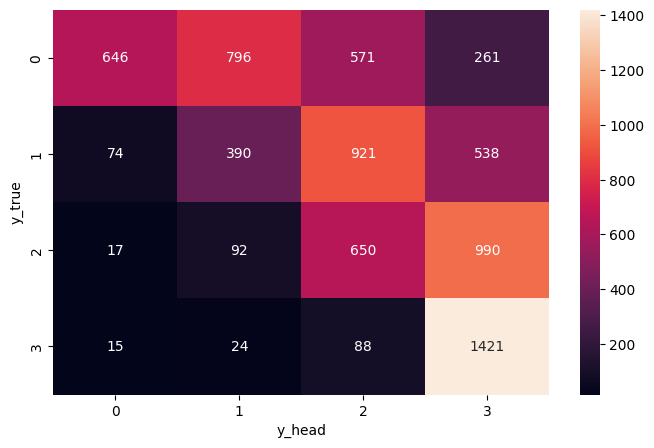

In [20]:
f, ax = plt.subplots(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test, bagnb_preds), annot=True, fmt=".0f", ax=ax)
plt.xlabel("y_head")
plt.ylabel("y_true")
plt.show()

In [21]:
!pip install yellowbrick

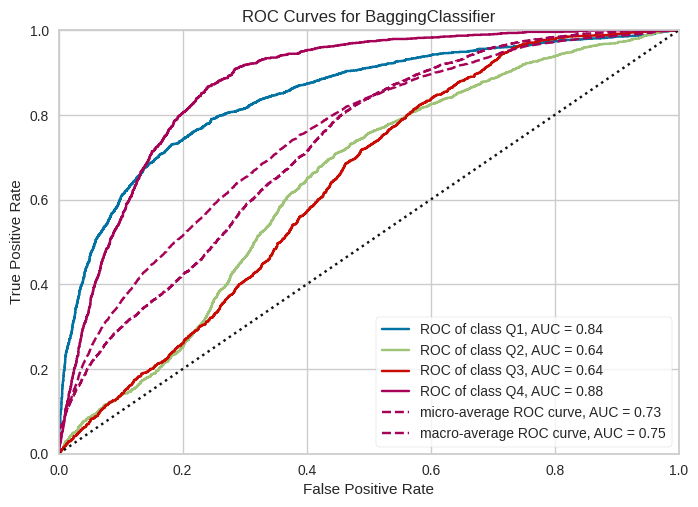

<Figure size 800x550 with 0 Axes>

In [22]:
from yellowbrick.classifier.rocauc import roc_auc
roc_auc(bagnb, X_train, y_train, X_test=X_test, y_test=y_test)
plt.savefig('roc_auc.png')